# 向量、矩阵、点积、范数 - 可视化

本 Notebook 生成三张图：
1. 向量夹角与点积
2. 矩阵线性变换前后网格
3. L1 与 L2 范数等值线

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/02_线性代数/assets')

## 图1：向量夹角与点积

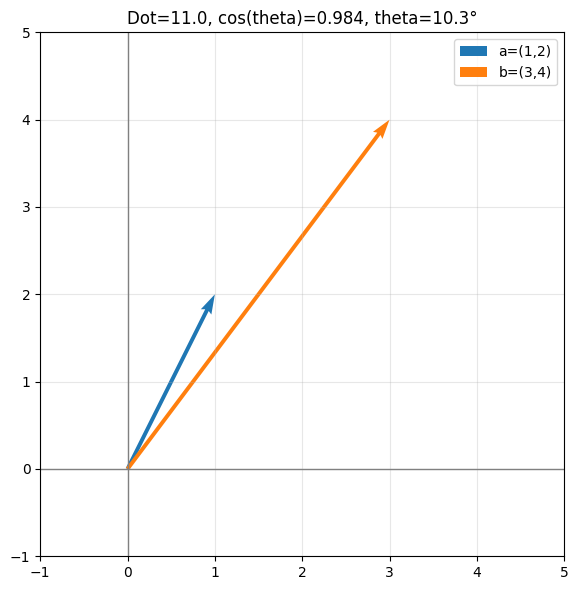

In [2]:
a = np.array([1.0, 2.0])
b = np.array([3.0, 4.0])
dot = a @ b
cos_theta = dot / (np.linalg.norm(a) * np.linalg.norm(b))
theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.quiver(0,0,a[0],a[1],angles='xy',scale_units='xy',scale=1,color='tab:blue',label='a=(1,2)')
plt.quiver(0,0,b[0],b[1],angles='xy',scale_units='xy',scale=1,color='tab:orange',label='b=(3,4)')
plt.xlim(-1,5)
plt.ylim(-1,5)
plt.gca().set_aspect('equal', 'box')
plt.grid(alpha=0.3)
plt.title(f'Dot={dot:.1f}, cos(theta)={cos_theta:.3f}, theta={theta:.1f}°')
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '16_vector_angle_dot.png', dpi=160)
plt.show()

## 图2：矩阵线性变换前后网格

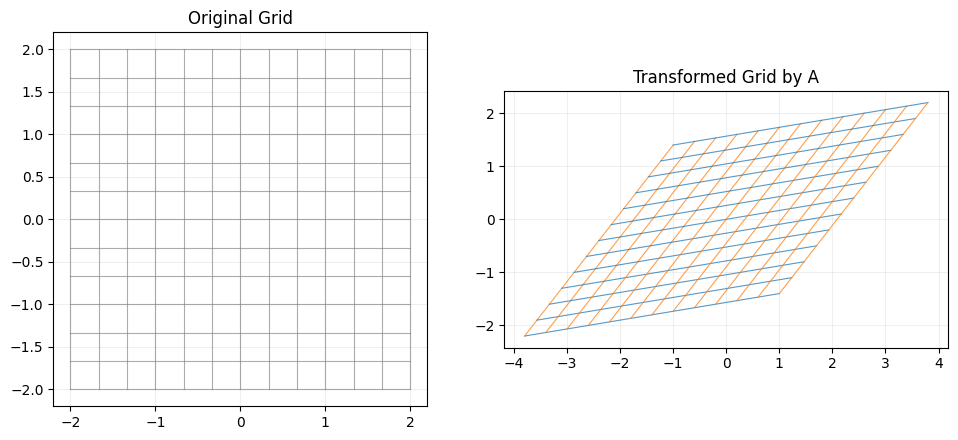

In [3]:
A = np.array([[1.2, 0.7], [0.2, 0.9]])
grid = np.linspace(-2, 2, 13)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4.5))

# 原网格
for c in grid:
    xs = np.linspace(-2,2,120)
    ys = np.full_like(xs,c)
    ax1.plot(xs, ys, color='gray', alpha=0.65, linewidth=0.8)

    ys2 = np.linspace(-2,2,120)
    xs2 = np.full_like(ys2,c)
    ax1.plot(xs2, ys2, color='gray', alpha=0.65, linewidth=0.8)

ax1.set_title('Original Grid')
ax1.set_aspect('equal','box')
ax1.grid(alpha=0.2)

# 变换后网格
for c in grid:
    xs = np.linspace(-2,2,120)
    ys = np.full_like(xs,c)
    uv = A @ np.vstack([xs, ys])
    ax2.plot(uv[0], uv[1], color='tab:blue', alpha=0.75, linewidth=0.8)

    ys2 = np.linspace(-2,2,120)
    xs2 = np.full_like(ys2,c)
    uv2 = A @ np.vstack([xs2, ys2])
    ax2.plot(uv2[0], uv2[1], color='tab:orange', alpha=0.75, linewidth=0.8)

ax2.set_title('Transformed Grid by A')
ax2.set_aspect('equal','box')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(assets_dir / '17_matrix_transform_grid.png', dpi=160)
plt.show()

## 图3：L1 与 L2 范数等值线

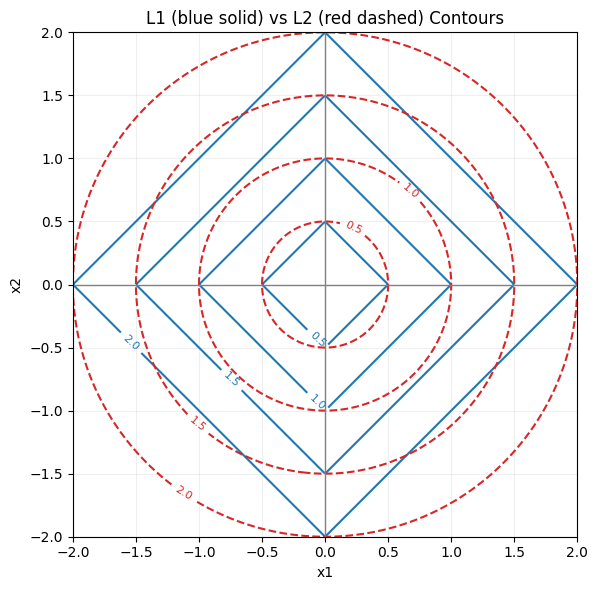

In [4]:
x = np.linspace(-2,2,300)
y = np.linspace(-2,2,300)
X, Y = np.meshgrid(x, y)
L1 = np.abs(X) + np.abs(Y)
L2 = np.sqrt(X**2 + Y**2)

plt.figure(figsize=(6.5,6))
c1 = plt.contour(X, Y, L1, levels=[0.5,1.0,1.5,2.0], colors='tab:blue')
c2 = plt.contour(X, Y, L2, levels=[0.5,1.0,1.5,2.0], colors='tab:red', linestyles='--')
plt.clabel(c1, inline=True, fontsize=8)
plt.clabel(c2, inline=True, fontsize=8)
plt.title('L1 (blue solid) vs L2 (red dashed) Contours')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axhline(0,color='gray',linewidth=1)
plt.axvline(0,color='gray',linewidth=1)
plt.gca().set_aspect('equal','box')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(assets_dir / '18_l1_l2_contours.png', dpi=160)
plt.show()

### 输出文件
- `assets/16_vector_angle_dot.png`
- `assets/17_matrix_transform_grid.png`
- `assets/18_l1_l2_contours.png`